# Doshisha Logo Detection System

## 1. 課題の目的

## 2. ライブラリの準備

## 3. Google Driveのマウント

## 4. データセットの準備

## 5. Selective Searchによる候補領域の抽出

## 6. CNNモデルの準備

## 7. CNNの学習

## 8. テスト画像での同志社ロゴ検出

## 9. 結果と考察

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

base_dir = "/content/drive/MyDrive/DoshishaLogoDetection"

positive_dir = os.path.join(base_dir, "data/positive")
negative_dir = os.path.join(base_dir, "data/negative")
test_dir = os.path.join(base_dir, "data/test")
output_dir = os.path.join(base_dir, "outputs")

for d in [positive_dir, negative_dir, test_dir, output_dir]:
  os.makedirs(d, exist_ok=True)

print("Created directories:")
print(positive_dir)
print(negative_dir)
print(test_dir)
print(output_dir)

Created directories:
/content/drive/MyDrive/DoshishaLogoDetection/data/positive
/content/drive/MyDrive/DoshishaLogoDetection/data/negative
/content/drive/MyDrive/DoshishaLogoDetection/data/test
/content/drive/MyDrive/DoshishaLogoDetection/outputs


In [3]:
!pip install -U opencv-contrib-python-headless==4.12.0.88

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

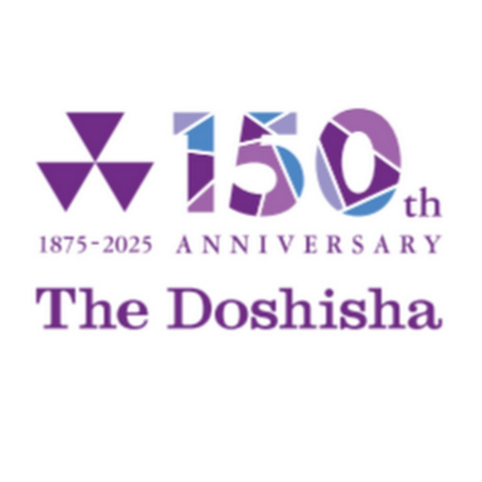

In [5]:
test_image_path = os.path.join(test_dir, "test.jpg")

img = Image.open(test_image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## 5. Selective Searchによる候補領域の抽出

Selective Searchは、画像の中で物体が存在する可能性のある領域を多数生成する手法である。
本課題では、画像全体を直接CNNに入力するのではなく、まずSelective Searchによって候補領域を抽出し、その各領域に対してCNNによる二値分類を行う。

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

test_image_path = os.path.join(test_dir, "test.jpg")
image_bgr = cv2.imread(test_image_path)

if image_bgr is None:
  raise FileNotFoundError(f"画像が読み込めません: {test_image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image_bgr)

ss.switchToSelectiveSearchFast()

rects = ss.process()

print(f"候補領域の数: {len(rects)}")
print("最初の5個: ", rects[:5])

候補領域の数: 1652
最初の5個:  [[607 527  99  81]
 [ 84 546  11  69]
 [799 347  10  52]
 [456 403  30   9]
 [518 436  38  40]]


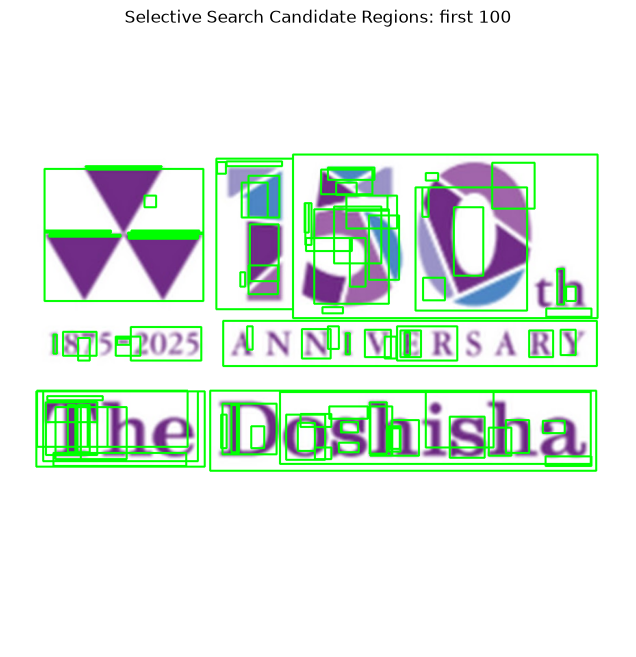

In [7]:
output_image = image_rgb.copy()

max_regions = 100

for (x, y, w, h) in rects[:max_regions]:
  cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(output_image)
plt.axis("off")
plt.title(f"Selective Search Candidate Regions: first {max_regions}")
plt.show()

絞り込み後の候補領域数: 1132
最初の5個: [(np.int32(607), np.int32(527), np.int32(99), np.int32(81)), (np.int32(518), np.int32(436), np.int32(38), np.int32(40)), (np.int32(565), np.int32(431), np.int32(88), np.int32(50)), (np.int32(804), np.int32(436), np.int32(22), np.int32(37)), (np.int32(176), np.int32(432), np.int32(103), np.int32(49))]


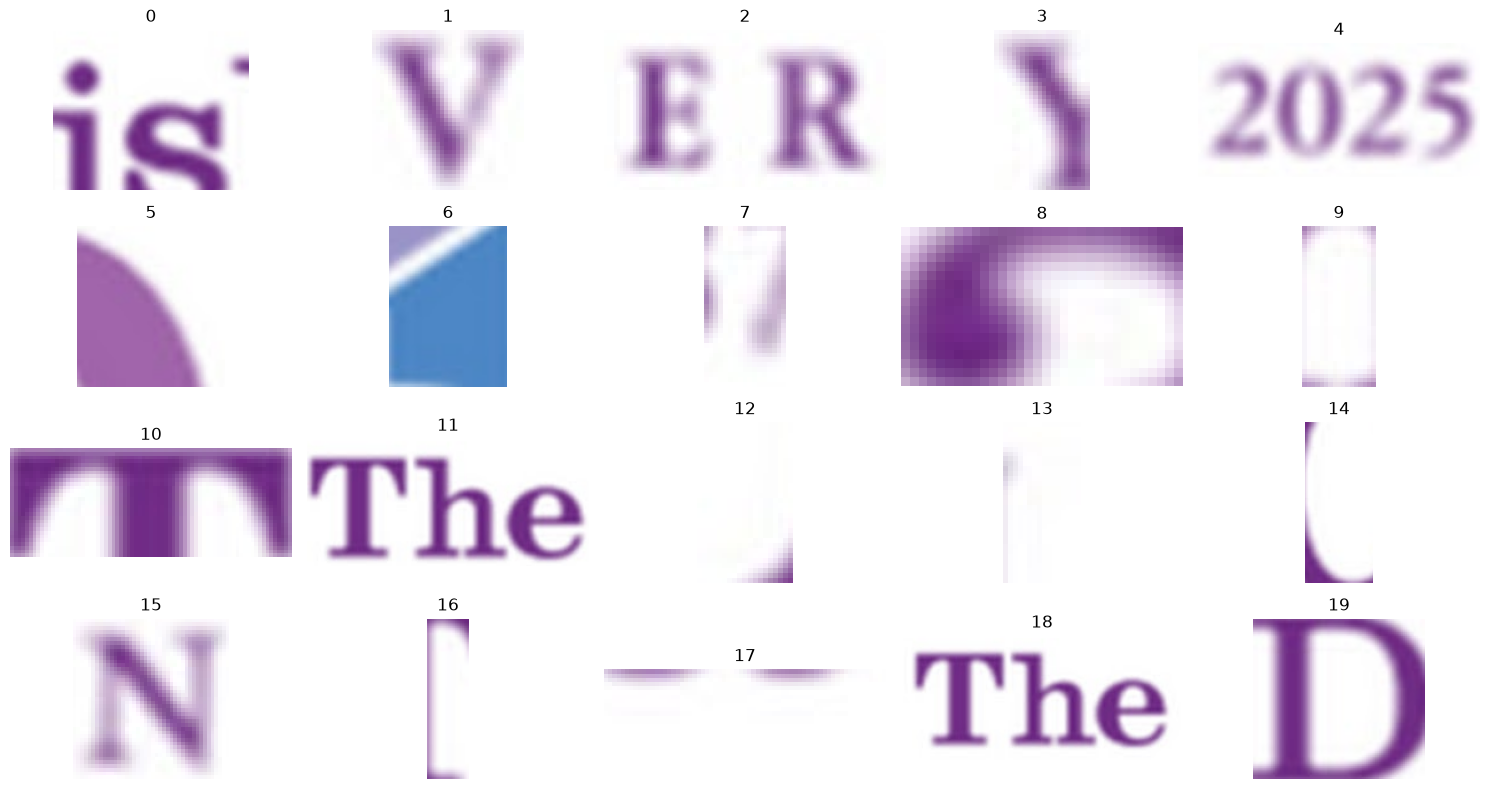

In [8]:
filtered_rects = []

image_h, image_w = image_rgb.shape[:2]

for (x, y, w, h) in rects:
  area = w * h
  aspect_ratio = w / h

  if area < 500:
    continue
  if area > image_w * image_h * 0.5:
    continue
  if aspect_ratio < 0.2 or aspect_ratio > 5.0:
    continue

  filtered_rects.append((x, y, w, h))

print(f"絞り込み後の候補領域数: {len(filtered_rects)}")
print("最初の5個:", filtered_rects[:5])

num_show = 20

plt.figure(figsize=(15, 8))

for i, (x, y, w, h) in enumerate(filtered_rects[:num_show]):
  crop = image_rgb[y:y+h, x:x+w]

  plt.subplot(4, 5, i + 1)
  plt.imshow(crop)
  plt.axis("off")
  plt.title(f"{i}")

plt.tight_layout()
plt.show()


In [9]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

positive_files = [
    f for f in os.listdir(positive_dir)
    if f.lower().endswith(image_extensions)
]

negative_files = [
    f for f in os.listdir(negative_dir)
    if f.lower().endswith(image_extensions)
]

print("positive images:", len(positive_files))
print("negative images:", len(negative_files))

print("positive sample:", positive_files[:5])
print("negative sample:", negative_files[:5])

positive images: 30
negative images: 80
positive sample: ['images (26).jpeg', 'images (1).jpeg', 'images (2).jpeg', 'images (3).jpeg', 'images (4).jpeg']
negative sample: ['negative_0000.jpg', 'negative_0001.jpg', 'negative_0002.jpg', 'negative_0003.jpg', 'negative_0004.jpg']


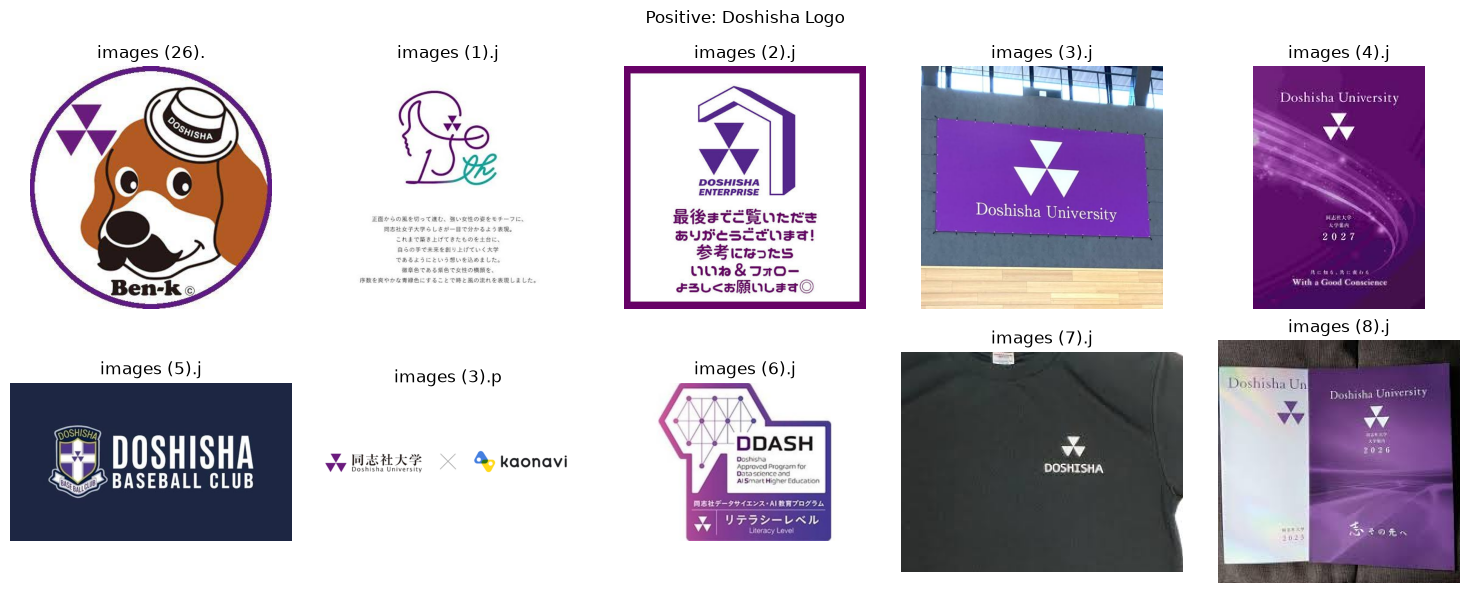

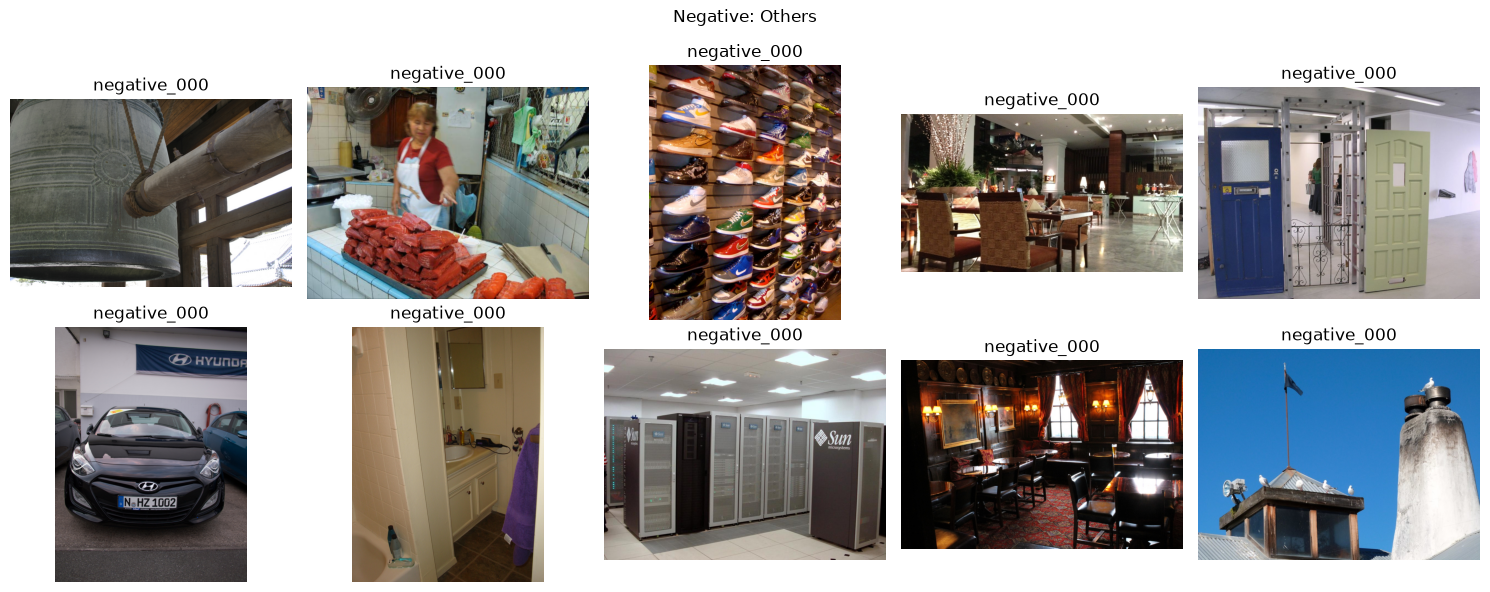

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_images(folder, files, title, num_images=10):
    plt.figure(figsize=(15, 6))

    for i, filename in enumerate(files[:num_images]):
        path = os.path.join(folder, filename)
        img = Image.open(path).convert("RGB")

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(filename[:12])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_images(positive_dir, positive_files, "Positive: Doshisha Logo")
show_sample_images(negative_dir, negative_files, "Negative: Others")